#### 1) Importing Necessary Libraires:

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima import auto_arima

from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

#### 2) Loading Data:

In [2]:
df = pd.read_csv('HospitalityEmployees.csv', index_col= 0, parse_dates= True)

In [3]:
df.head()

,Employees
Date,
1990-01-01,1064.5
1990-02-01,1074.5
1990-03-01,1090.0
1990-04-01,1097.4
1990-05-01,1108.7


In [4]:
df.shape

(348, 1)

In [5]:
df.describe()

,Employees
count,348.000000
mean,1452.506897
std,256.604914
min,1064.500000
25%,1238.050000
50%,1436.200000
75%,1586.300000
max,2022.100000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 348 entries, 1990-01-01 to 2018-12-01
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Employees  348 non-null    float64
dtypes: float64(1)
memory usage: 5.4 KB


##### Adding Index Frequency:

In [7]:
df.index

DatetimeIndex(['1990-01-01', '1990-02-01', '1990-03-01', '1990-04-01',
               '1990-05-01', '1990-06-01', '1990-07-01', '1990-08-01',
               '1990-09-01', '1990-10-01',
               ...
               '2018-03-01', '2018-04-01', '2018-05-01', '2018-06-01',
               '2018-07-01', '2018-08-01', '2018-09-01', '2018-10-01',
               '2018-11-01', '2018-12-01'],
              dtype='datetime64[ns]', name='Date', length=348, freq=None)

In [8]:
df.index.freq = 'MS'

##### Visualizing Data:

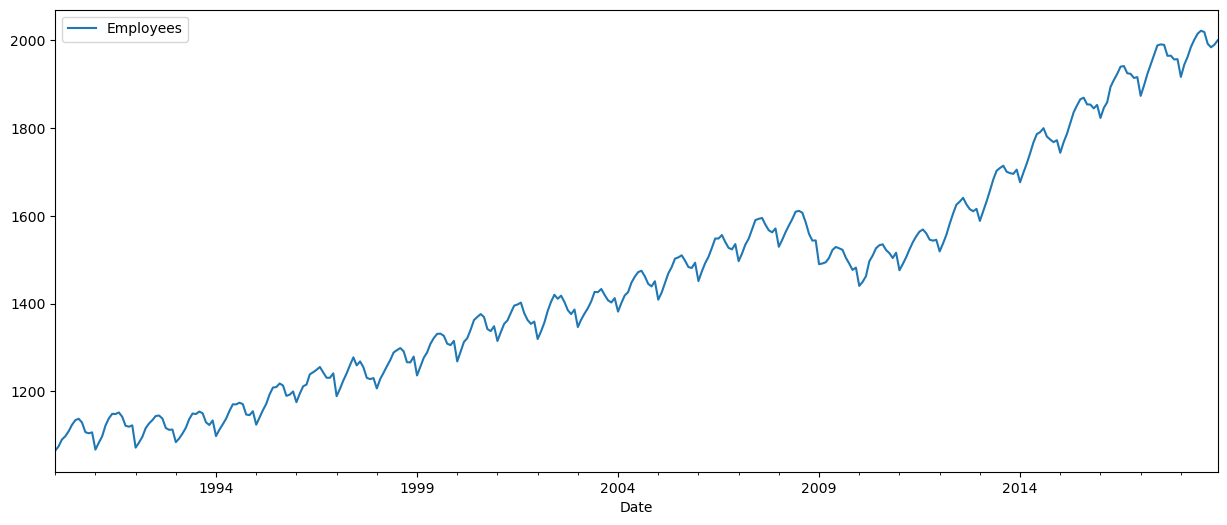

In [11]:
df.plot(kind= 'line', figsize= (15,6))
plt.show()

#### 3) ETS Decomposition:

In [12]:
decomp = seasonal_decompose(df['Employees'])

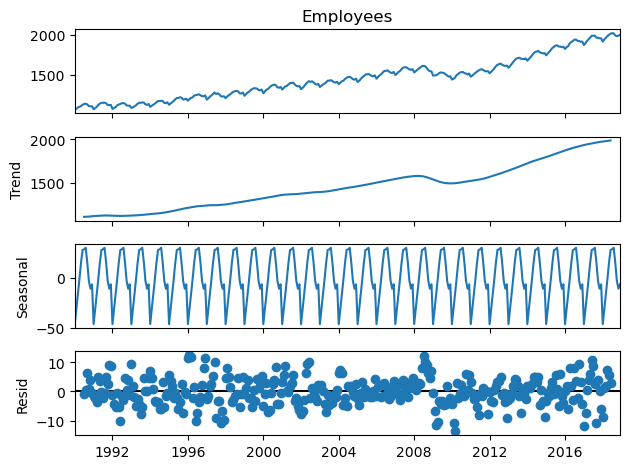

In [13]:
decomp.plot()
plt.show()

#### 4) Order Selection by AUTO ARIMA:

In [16]:
grid = auto_arima(y= df['Employees'], 
                  seasonal= True,
                  m= 12,
                 trace= True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=2215.014, Time=2.13 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=2974.636, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.63 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=2707.381, Time=0.47 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=2980.790, Time=0.03 sec
 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=inf, Time=1.53 sec
 ARIMA(2,1,2)(1,0,0)[12] intercept   : AIC=2340.935, Time=1.07 sec
 ARIMA(2,1,2)(2,0,1)[12] intercept   : AIC=2230.159, Time=6.40 sec
 ARIMA(2,1,2)(1,0,2)[12] intercept   : AIC=inf, Time=5.89 sec
 ARIMA(2,1,2)(0,0,0)[12] intercept   : AIC=inf, Time=0.62 sec
 ARIMA(2,1,2)(0,0,2)[12] intercept   : AIC=inf, Time=5.11 sec
 ARIMA(2,1,2)(2,0,0)[12] intercept   : AIC=2264.870, Time=4.03 sec
 ARIMA(2,1,2)(2,0,2)[12] intercept   : AIC=inf, Time=6.86 sec
 ARIMA(1,1,2)(1,0,1)[12] intercept   : AIC=2227.513, Time=1.02 sec
 ARIMA(2,1,1)(1,0,1)[12] intercept   : AIC=2225.1

In [17]:
grid.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  348
Model:             SARIMAX(1, 1, 2)x(1, 0, [1], 12)   Log Likelihood               -1098.252
Date:                              Sat, 20 Dec 2025   AIC                           2208.504
Time:                                      19:04:49   BIC                           2231.600
Sample:                                  01-01-1990   HQIC                          2217.700
                                       - 12-01-2018                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9245      0.045     20.498      0.000       0.836       1.013
ma.L1         -0.9439      0.070    -13.565      0.000      -1.080      -0.808
ma.L2          0.1286      0.060      2.150      0.032       0.011       0.246
ar.S.L12       0.9972      0.001    703.736      0.000       0.994       1.000
ma.S.L12      -0.7491      0.043    -17.356      0.000      -0.834      -0.664
sigma2        29.2975      1.718     17.054      0.000      25.930      32.664
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                67.42
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               0.86   Skew:                            -0.11
Prob(H) (two-sided):                  0.40   Kurtosis:                         5.15
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#### 5) SARIMA(1,1,2)(1,0,1)[12] Model:

##### Train Test Split:

In [18]:
len(df)

348

In [19]:
train_data = df[:-24]
test_data = df[-24:]
print(train_data.shape, test_data.shape)

(324, 1) (24, 1)


##### Model:

In [21]:
model = SARIMAX(endog= train_data,
               order= (1, 1, 2),
               seasonal_order= (1, 0, 1, 12))

result = model.fit()

In [22]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                            Employees   No. Observations:                  324
Model:             SARIMAX(1, 1, 2)x(1, 0, [1], 12)   Log Likelihood               -1017.185
Date:                              Sat, 20 Dec 2025   AIC                           2046.369
Time:                                      19:08:11   BIC                           2069.035
Sample:                                  01-01-1990   HQIC                          2055.417
                                       - 12-01-2016                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9202      0.045     20.531      0.000       0.832       1.008
ma.L1         -0.9579      0.072    -13.313      0.000      -1.099      -0.817
ma.L2          0.1611      0.062      2.600      0.009       0.040       0.283
ar.S.L12       0.9971      0.001    680.852      0.000       0.994       1.000
ma.S.L12      -0.7463      0.047    -15.957      0.000      -0.838      -0.655
sigma2        28.1538      1.628     17.292      0.000      24.963      31.345
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                87.86
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               0.78   Skew:                            -0.17
Prob(H) (two-sided):                  0.20   Kurtosis:                         5.53
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

##### Predictions on Test Data:

In [23]:
start = len(train_data)
end = len(train_data) + len(test_data) -1

In [24]:
preds = result.predict(start= start,
                      end= end)

In [25]:
preds.head()

2017-01-01    1885.639747
2017-02-01    1905.307745
2017-03-01    1921.952440
2017-04-01    1947.073033
2017-05-01    1967.153572
Freq: MS, Name: predicted_mean, dtype: float64

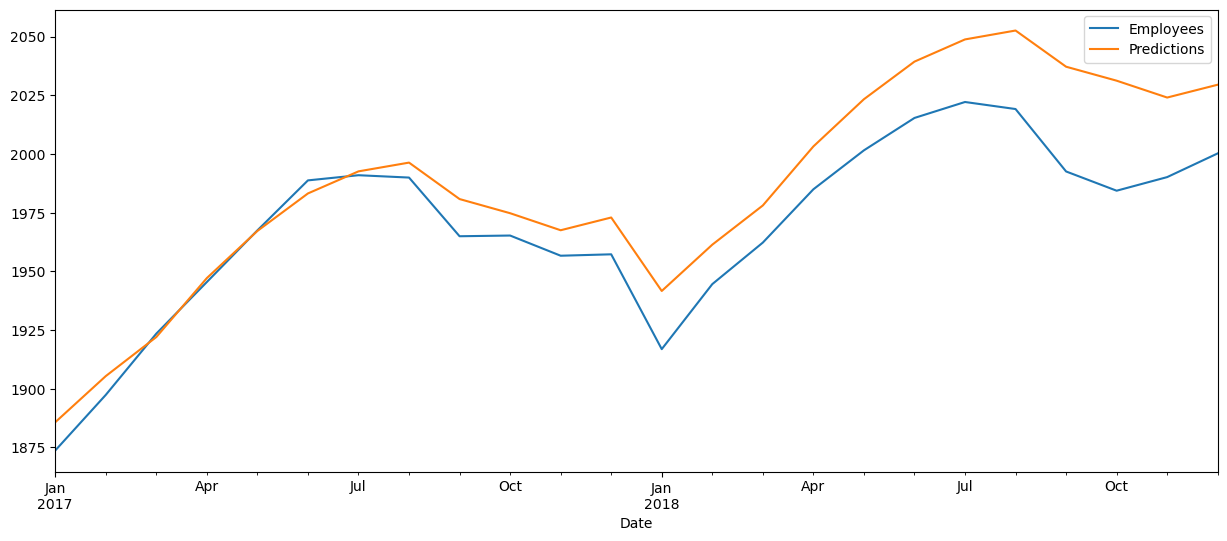

In [26]:
# Plotting Test Data and Predictions:

test_data['Employees'].plot(figsize= (15,6), legend= True)
preds.plot(label= 'Predictions', legend= True)
plt.show()

##### Model Evaluation:

In [27]:
# Model Evaluation:

np.sqrt(mean_squared_error(test_data['Employees'], preds))

np.float64(21.9369971509207)

In [28]:
test_data['Employees'].mean()

np.float64(1968.9166666666667)

##### Training Model on Full Data and Future Predictions::

In [29]:
final_model = SARIMAX(endog= df['Employees'], 
                     order= (1, 1, 2),
                     seasonal_order= (1, 0, 1, 12))

result = final_model.fit()

In [30]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                            Employees   No. Observations:                  348
Model:             SARIMAX(1, 1, 2)x(1, 0, [1], 12)   Log Likelihood               -1098.252
Date:                              Sat, 20 Dec 2025   AIC                           2208.504
Time:                                      19:11:52   BIC                           2231.600
Sample:                                  01-01-1990   HQIC                          2217.700
                                       - 12-01-2018                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9245      0.045     20.498      0.000       0.836       1.013
ma.L1         -0.9439      0.070    -13.565      0.000      -1.080      -0.808
ma.L2          0.1286      0.060      2.150      0.032       0.011       0.246
ar.S.L12       0.9972      0.001    703.736      0.000       0.994       1.000
ma.S.L12      -0.7491      0.043    -17.356      0.000      -0.834      -0.664
sigma2        29.2975      1.718     17.054      0.000      25.930      32.664
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                67.42
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               0.86   Skew:                            -0.11
Prob(H) (two-sided):                  0.40   Kurtosis:                         5.15
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [31]:
forecast = result.predict(start= len(df),
                          end= len(df)+23)

In [32]:
forecast.head()

2019-01-01    1963.878100
2019-02-01    1986.818547
2019-03-01    2005.999387
2019-04-01    2030.334328
2019-05-01    2050.314906
Freq: MS, Name: predicted_mean, dtype: float64

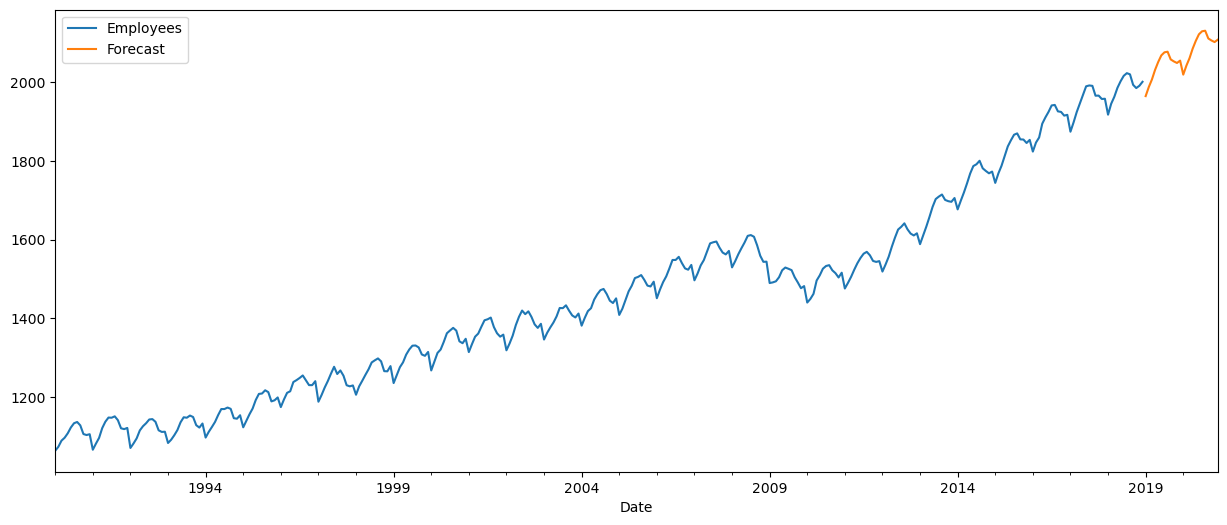

In [33]:
# Plotting Historic Data and Forecast:

df['Employees'].plot(figsize= (15,6), legend= True)
forecast.plot(label= 'Forecast', legend= True)
plt.show()